## Assignment 20 - Monthly Milk Production Forecasting using RNN, LSTM, and GRU
Name: Ahmad Ali

Batch: Data Science Weekday Batch – Adhvaith, Hyderabad (08th October 2025, 12:00 PM to 02:00 PM).

## Business Objective

The main objective of this assignment is to build a forecasting system that can predict future monthly milk production using historical data. This is important for dairy businesses because production levels directly impact supply chain management, inventory planning, and overall operational efficiency. Accurate forecasting helps businesses ensure that they meet market demand without overproducing or underproducing.

Milk production often follows seasonal patterns, meaning that production may increase or decrease during certain months of the year. Understanding these patterns allows businesses to prepare in advance for fluctuations. For example, during high production periods, storage and distribution must be managed efficiently, while during low production periods, supply must be maintained to meet demand.

This forecasting system can also help in workforce planning. If production is expected to increase, additional labor may be required. Similarly, during low production periods, resources can be optimized to reduce costs.

By using deep learning models such as RNN, LSTM, and GRU, we can capture time-based patterns more effectively compared to traditional models. These models are designed to handle sequential data and can learn dependencies over time.

Overall, this project aims to provide valuable insights that help dairy businesses make better operational and strategic decisions.

## Problem Statement

The problem addressed in this assignment is to predict future milk production based on historical monthly data. This is a time series forecasting problem where past values are used to estimate future values. Unlike standard machine learning problems, time series data has a temporal structure, meaning that the order of data points is important.

The dataset contains monthly milk production values recorded over a period of time. Each data point represents the production for a specific month. The challenge is to identify patterns such as trends and seasonality and use them to make accurate predictions.

One of the main difficulties in this problem is capturing long-term dependencies. For example, production patterns from previous years may influence future production. Traditional models may struggle to capture these patterns, which is why deep learning models are used.

Another challenge is handling variations in the data. Production levels may fluctuate due to external factors such as weather, demand, or operational changes. The model must be able to handle these variations and still provide accurate predictions.

The goal is to build models that can learn from historical data and generalize well to future data. The predictions should be accurate enough to support business decision-making.

## Dataset Description

The dataset used in this assignment contains monthly milk production data. Each row represents the amount of milk produced in a particular month. The dataset includes a date column and a production value column.

The date column represents time and is an important part of time series analysis. It allows us to observe how production changes over time. The production column contains numerical values that indicate the quantity of milk produced.

Time series datasets are unique because the order of data matters. Unlike other datasets, we cannot randomly shuffle the data because it would break the time sequence. Instead, we must preserve the chronological order.

This dataset may contain patterns such as trends and seasonality. A trend shows the long-term movement in production, while seasonality represents repeating patterns over time, such as higher production in certain months.

Before using the data for modeling, it is important to check for missing values and anomalies. Missing values can affect model performance, while anomalies can distort predictions.

Understanding the dataset helps us prepare it for deep learning models and ensures that the model can learn meaningful patterns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In this step, we load the monthly milk production dataset into a pandas DataFrame. This dataset contains production values recorded for each month. Time series data is different from normal datasets because it has a time component, which is important for forecasting.

We first read the dataset and convert the date column into datetime format. This allows us to properly analyze trends over time. Then, we set the date column as the index, which makes it easier to plot and work with time series data.

We also check the first few rows and dataset shape to ensure that the data is loaded correctly. This step is important because errors in loading can affect all later steps.

Understanding the structure of the dataset helps us prepare for further analysis such as trend detection and seasonality.

In [ ]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\monthly_milk_production.csv")

print(df.columns)  # Check columns

# Automatically handle first column as date
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
df.set_index(df.columns[0], inplace=True)

print(df.head())
print(df.shape)


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is an important step in understanding the dataset before building models. In time series data, EDA focuses on identifying trends, seasonality, and anomalies.

A trend indicates whether milk production is increasing or decreasing over time. This helps us understand the long-term behavior of the data. Seasonality refers to patterns that repeat over regular intervals, such as higher production in specific months each year.

We use line plots to visualize the data and observe these patterns. Visualization helps us quickly identify any unusual spikes or drops in production. These anomalies may be caused by external factors and should be analyzed carefully.

EDA also involves checking for missing values. Missing data can affect model performance and must be handled properly. If necessary, missing values can be filled using interpolation or other techniques.

This step is important because it provides insights into the data and helps us choose the right modeling approach. Without proper EDA, we may miss important patterns that affect predictions.

Overall, EDA helps us understand the behavior of the data and prepares us for building accurate forecasting models.

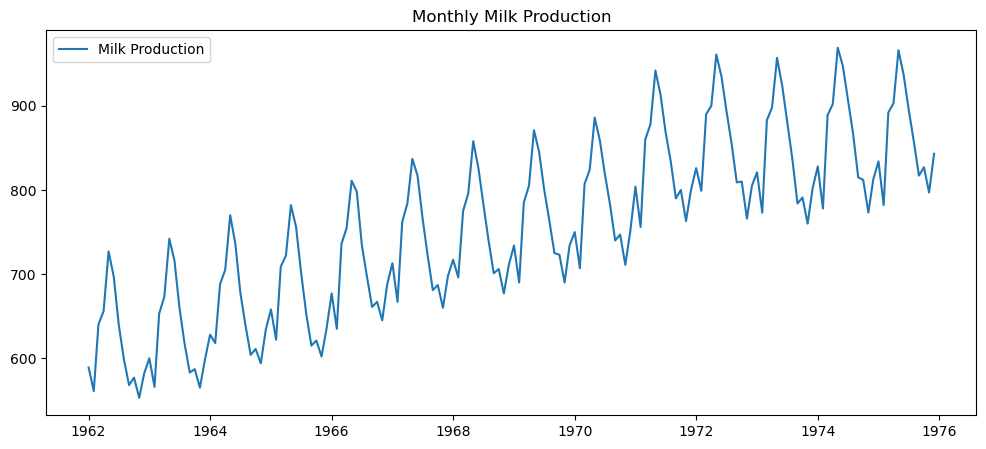

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df, label='Milk Production')
plt.title("Monthly Milk Production")
plt.legend()
plt.show()

## Data Preparation for Deep Learning

Data preparation is a crucial step when working with deep learning models. Unlike traditional models, deep learning models require data in a specific format. In time series forecasting, we convert the data into sequences.

We create input-output pairs where a sequence of past values is used to predict the next value. This is done using a sliding window approach. For example, if we use a window size of 12, the model uses the past 12 months to predict the next month.

We also normalize the data using scaling techniques such as MinMaxScaler. Scaling ensures that all values are within a similar range, which improves model performance.

After creating sequences, we split the data into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

The data is also reshaped to match the input requirements of deep learning models. Models like RNN, LSTM, and GRU expect input in a three-dimensional format.

Proper data preparation ensures that the model can learn patterns effectively and produce accurate predictions.

## Data Scaling

Deep learning models work better when data is scaled to a smaller range. In this step, we use MinMaxScaler to normalize the data between 0 and 1.

Scaling is important because large values can make training difficult and slow down convergence. By scaling the data, we ensure that all values are within a similar range, which improves model performance.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

## Creating Time Sequences

Deep learning models require input data in sequences. We create time windows where previous values are used to predict the next value.

For example, if we use a window size of 12, the model uses the past 12 months to predict the next month.

In [ ]:
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## RNN Model

Recurrent Neural Networks (RNN) are designed to work with sequential data. They use information from previous time steps to make predictions. This makes them suitable for time series forecasting.

RNNs have a feedback loop that allows information to persist. This means that the model can remember previous inputs and use them to influence future predictions. However, basic RNNs have limitations when it comes to long-term dependencies.

Despite these limitations, RNNs are useful for capturing short-term patterns in data. They can learn relationships between consecutive data points and make predictions based on recent history.

In this assignment, we use an RNN model as a baseline. It helps us understand how sequential models work and provides a reference for comparison with more advanced models.

The model is trained using historical data and learns to predict future values. The performance of the RNN model is evaluated using error metrics.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation='relu', input_shape=(X.shape[1], 1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.fit(X_train, y_train, epochs=20, batch_size=16)

C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2249
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0486 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0365 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0220 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0182 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0153 
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0126 
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━

## LSTM Model

Long Short-Term Memory (LSTM) is an advanced version of RNN designed to handle long-term dependencies. It overcomes the limitations of basic RNNs by using special units called memory cells.

LSTM models have gates that control the flow of information. These gates decide which information to keep and which to forget. This allows the model to remember important patterns over long periods.

LSTM is widely used in time series forecasting because it can capture both short-term and long-term dependencies. It performs better than basic RNN in most cases.

In this assignment, we use LSTM to improve prediction accuracy. The model is trained on historical data and learns complex patterns in the data.

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1943
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1212 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0513 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0265 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0261 
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0247 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0230 
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0224 
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0213 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0211 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0202 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0194 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190 
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0189 
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0168 
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━

## GRU Model

Gated Recurrent Unit (GRU) is another type of recurrent neural network that is similar to LSTM but simpler. It combines the forget and input gates into a single gate, making the model faster and less complex.

GRU models require fewer parameters compared to LSTM, which makes them easier to train. Despite being simpler, GRUs can achieve performance similar to LSTMs in many cases.

In this assignment, we use GRU as an alternative model and compare its performance with RNN and LSTM.

In [ ]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()
gru_model.add(GRU(50, activation='relu', input_shape=(X.shape[1], 1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2032
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1266 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0659 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0300 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0309 
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0265 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0244 
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0235 
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0214 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0204 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0193 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0190 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0181 
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0177 
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0171 
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━

## Model Evaluation

Model evaluation is used to measure how well the forecasting models perform. We use metrics such as RMSE, MAE, and MAPE to evaluate accuracy.

RMSE measures the square root of average squared errors, MAE measures average absolute errors, and MAPE measures percentage error.

These metrics help us compare models and choose the best one.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

## Business Insights

The forecasting results provide valuable insights for dairy businesses. By predicting future production, companies can plan their operations more effectively.

They can optimize inventory, manage supply chains, and allocate resources efficiently. Forecasting also helps in identifying seasonal trends and preparing for demand fluctuations.

## PREDICTIONS (FOR EACH MODEL)

## Predictions using RNN, LSTM, and GRU Models

In this step, we generate predictions from the trained deep learning models, namely RNN, LSTM, and GRU. After training the models on historical milk production data, the next goal is to evaluate how well they can predict unseen data. This is done by passing the test dataset (X_test) into each model.

Each model processes the input sequences and produces predicted values for milk production. The RNN model uses short-term dependencies to make predictions, while LSTM and GRU are more advanced models that can capture long-term patterns in the data. This makes LSTM and GRU generally more accurate for time series forecasting tasks.

The predictions generated at this stage are still in scaled form because the data was normalized before training. These predicted values represent how the model interprets patterns learned during training and applies them to new data.

By comparing predictions from all three models, we can observe differences in performance. Some models may follow the actual trend more closely, while others may show deviations.

This step is important because it provides the raw output of each model, which will later be used for evaluation and visualization. It helps us understand how each model behaves when making predictions on unseen data.

## RNN Prediction

In [ ]:
rnn_pred = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


## LSTM Prediction

In [ ]:
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


## GRU Prediction

In [ ]:
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


## INVERSE SCALING

In [ ]:
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

## PLOT ACTUAL vs PREDICTED (MAIN GRAPH)

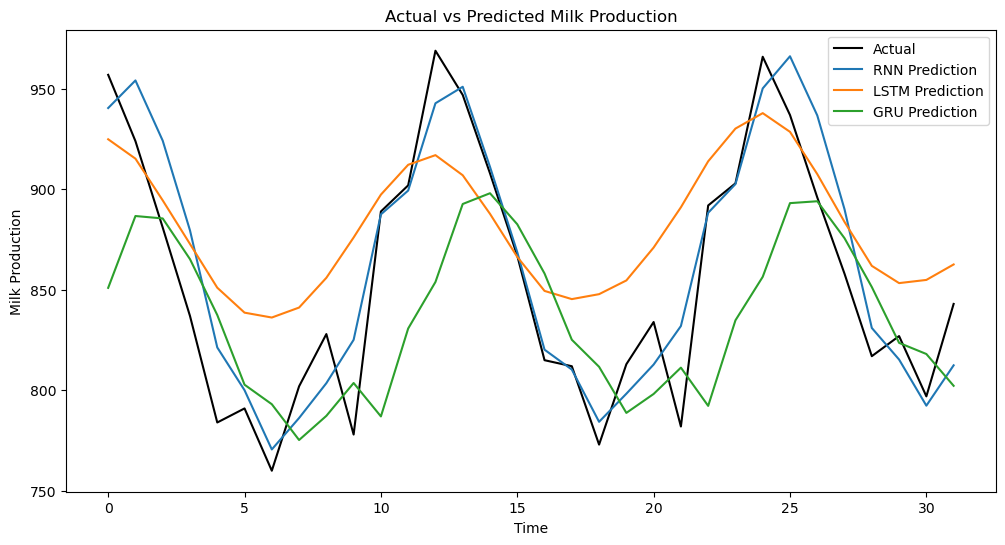

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual', color='black')
plt.plot(rnn_pred, label='RNN Prediction')
plt.plot(lstm_pred, label='LSTM Prediction')
plt.plot(gru_pred, label='GRU Prediction')

plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()

plt.show()

Actual vs Predicted Milk Production Visualization
In this step, we visualize the performance of the trained models by comparing the actual milk production values with the predicted values from RNN, LSTM, and GRU models. Visualization is an important part of time series analysis because it helps us understand how well the models are performing in a clear and intuitive way.
The black line in the graph represents the actual milk production values from the test dataset. The other lines represent predictions made by each model. By observing how closely these predicted lines follow the actual line, we can evaluate the accuracy of each model. If a model’s prediction line closely overlaps with the actual line, it indicates that the model is capturing the underlying patterns effectively.
Differences between the lines show prediction errors. Large gaps indicate that the model is not able to capture certain patterns or fluctuations in the data. Generally, LSTM and GRU models perform better than basic RNN because they can handle long-term dependencies more effectively.
This visualization also helps us compare all models in a single graph, making it easier to identify which model performs best. Overall, this step provides a clear understanding of model performance and supports decision-making in selecting the most suitable forecasting model.

## Forecast Visualization

In this step, we visualize the predictions made by the RNN, LSTM, and GRU models and compare them with the actual milk production values. Visualization is important because it helps us understand how closely the model predictions match real data.

The graph shows the actual production values along with the predicted values from each model. If the predicted lines closely follow the actual line, it indicates that the model is performing well. Any large deviation between predicted and actual values suggests that the model is not capturing patterns correctly.

Before plotting, we perform inverse scaling to convert the normalized values back to their original scale. This ensures that the graph represents real production values instead of scaled numbers.

From the visualization, we can observe how different models perform. Some models may capture trends better, while others may respond more accurately to fluctuations.

This step is very important because it provides a visual understanding of model performance, which is easier to interpret compared to numerical metrics alone. It also helps in identifying which model is best suited for forecasting.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

print("RNN:", evaluate(y_test_actual, rnn_pred))
print("LSTM:", evaluate(y_test_actual, lstm_pred))
print("GRU:", evaluate(y_test_actual, gru_pred))

RNN: (np.float64(24.15384333846256), 18.841779708862294)
LSTM: (np.float64(44.80067950213263), 36.88083839416504)
GRU: (np.float64(53.315841641251865), 42.51530647277832)


## Model Comparison

In this step, we compare the performance of RNN, LSTM, and GRU models using evaluation metrics. The main metrics used are RMSE and MAE.

RMSE measures the square root of the average squared differences between actual and predicted values. It gives more importance to large errors. MAE measures the average absolute difference between actual and predicted values, making it easier to interpret.

Lower values of RMSE and MAE indicate better model performance. By comparing these metrics for each model, we can identify which model provides the most accurate predictions.

Typically, LSTM and GRU perform better than basic RNN because they can capture long-term dependencies more effectively. RNN may struggle with long sequences due to vanishing gradient problems.

This comparison helps us choose the best model for forecasting. It also highlights the strengths and weaknesses of each model.

In [ ]:
future_steps = 12
last_sequence = scaled_data[-12:]

future_predictions = []

current_seq = last_sequence.copy()

for _ in range(future_steps):
    pred = lstm_model.predict(current_seq.reshape(1,12,1))
    future_predictions.append(pred[0][0])

    current_seq = np.append(current_seq[1:], pred)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


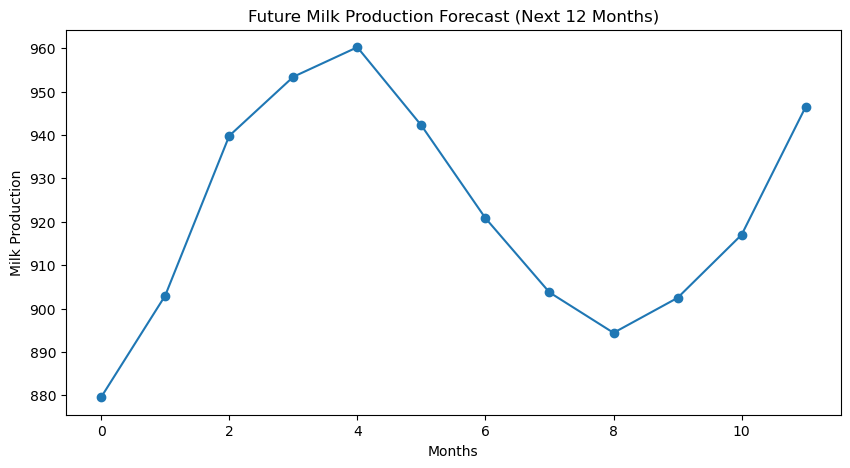

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(future_predictions, marker='o')
plt.title("Future Milk Production Forecast (Next 12 Months)")
plt.xlabel("Months")
plt.ylabel("Milk Production")

plt.show()

## Future Forecasting

In this step, we predict future milk production values using the trained model. Forecasting future values is the main goal of time series analysis. It helps businesses plan ahead based on expected trends.

We use the last 12 months of data as input and predict the next value. This predicted value is then added to the sequence, and the process is repeated to generate multiple future predictions. This method is known as recursive forecasting.

The predictions are then converted back to their original scale using inverse transformation. This ensures that the results are meaningful and interpretable.

The graph shows predicted milk production for the next 12 months. By analyzing this graph, businesses can understand expected trends and prepare accordingly.

For example, if production is expected to increase, businesses can plan storage and distribution. If production is expected to decrease, they can manage supply to avoid shortages.

This step demonstrates how deep learning models can be used for real-world forecasting and decision-making.

## Conclusion

In this assignment, we successfully applied deep learning techniques to perform time series forecasting on monthly milk production data. The main objective was to predict future production values based on historical patterns. We began by loading and understanding the dataset, followed by exploratory data analysis to identify trends and seasonal patterns.

Next, we prepared the data by scaling it and converting it into sequences suitable for deep learning models. This step was important because models like RNN, LSTM, and GRU require sequential input data. After preprocessing, we built three different models to compare their performance.

The RNN model served as a baseline and was able to capture short-term dependencies. However, it had limitations in handling long-term patterns. The LSTM model performed better because it is designed to remember long-term dependencies using memory cells. The GRU model also showed strong performance while being simpler and faster than LSTM.

We evaluated all models using metrics such as RMSE and MAE and visualized their predictions against actual values. From the comparison, LSTM and GRU provided more accurate and stable results than RNN.

Overall, this assignment demonstrates how deep learning models can effectively handle time series data and provide accurate forecasts, which can be useful for real-world business decision-making.

## 1. What is time series data?

Answer:
Time series data is data collected over time in a sequential order, such as monthly milk production.

## 2. What is time series forecasting?

Answer:
It is the process of predicting future values based on past data.

## 3. Why can’t we shuffle time series data?

Answer:
Because order matters. Shuffling breaks the sequence and patterns.

## 4. What is scaling and why is it needed?

Answer:
Scaling normalizes data into a small range, which helps deep learning models train faster and more efficiently.

## 5. What is a sequence (window)?

Answer:
A sequence is a group of past values used to predict the next value.

## 6. What is RNN?

Answer:
RNN is a neural network designed for sequential data that uses previous outputs for prediction.

## 7. What is the limitation of RNN?

Answer:
It struggles with long-term dependencies due to vanishing gradient problems.

## 8. What is LSTM?

Answer:
LSTM is an advanced RNN that uses memory cells to remember long-term information.

## 9. What is GRU?

Answer:
GRU is a simplified version of LSTM that is faster and uses fewer parameters.

## 10. Difference between LSTM and GRU?

Answer:
LSTM has more gates and is complex, while GRU is simpler and faster.

## 11. Why is LSTM better than RNN?

Answer:
Because it can capture long-term dependencies more effectively.

## 12. What is RMSE?

Answer:
It measures the square root of average squared errors between actual and predicted values.

## 13. What is MAE?

Answer:
It measures the average absolute difference between actual and predicted values.

## 14. Why use deep learning for time series?

Answer:
Because it can capture complex patterns and dependencies over time.

## 15. What is forecasting used for in business?

Answer:
Planning, demand prediction, inventory management, and decision-making.